In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/reemalmutairi1/hr-data/hr_data.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv('/kaggle/input/datasets/reemalmutairi1/hr-data/hr_data.csv')
print(df.shape)
print(df.head())

(1000, 10)
   Employee_ID Department  Position  Gender  Age  Salary  Experience  \
0            1    Finance  Director    Male   22    6374          17   
1            2  Marketing  Director  Female   45    4519           3   
2            3         HR  Director    Male   56    8777           5   
3            4  Marketing  Director  Female   45   10935          19   
4            5  Marketing  Director    Male   38    9093          12   

   Performance  Satisfaction  Left_Company  
0           87             6             0  
1           68             7             0  
2           79             2             0  
3           78             9             0  
4           98             1             0  


In [3]:
# Step 2: Basic Analysis
print("Department Distribution:")
print(df['Department'].value_counts())
print("\nAverage Salary by Department:")
print(df.groupby('Department')['Salary'].mean().round(2).sort_values(ascending=False))

Department Distribution:
Department
Sales        210
Finance      206
Marketing    204
HR           190
IT           190
Name: count, dtype: int64

Average Salary by Department:
Department
Finance      9300.85
HR           9190.82
Marketing    9133.14
IT           9057.73
Sales        8838.17
Name: Salary, dtype: float64


In [4]:
# Step 3: Performance Analysis
print("Average Performance by Department:")
print(df.groupby('Department')['Performance'].mean().round(2).sort_values(ascending=False))
print("\nEmployees who Left Company:")
print(df['Left_Company'].value_counts())
print("\nLeft Rate by Department:")
print(df.groupby('Department')['Left_Company'].mean().round(2).sort_values(ascending=False))

Average Performance by Department:
Department
HR           79.82
Sales        79.81
IT           79.36
Finance      79.14
Marketing    78.75
Name: Performance, dtype: float64

Employees who Left Company:
Left_Company
0    793
1    207
Name: count, dtype: int64

Left Rate by Department:
Department
Finance      0.23
HR           0.21
Marketing    0.21
Sales        0.20
IT           0.18
Name: Left_Company, dtype: float64


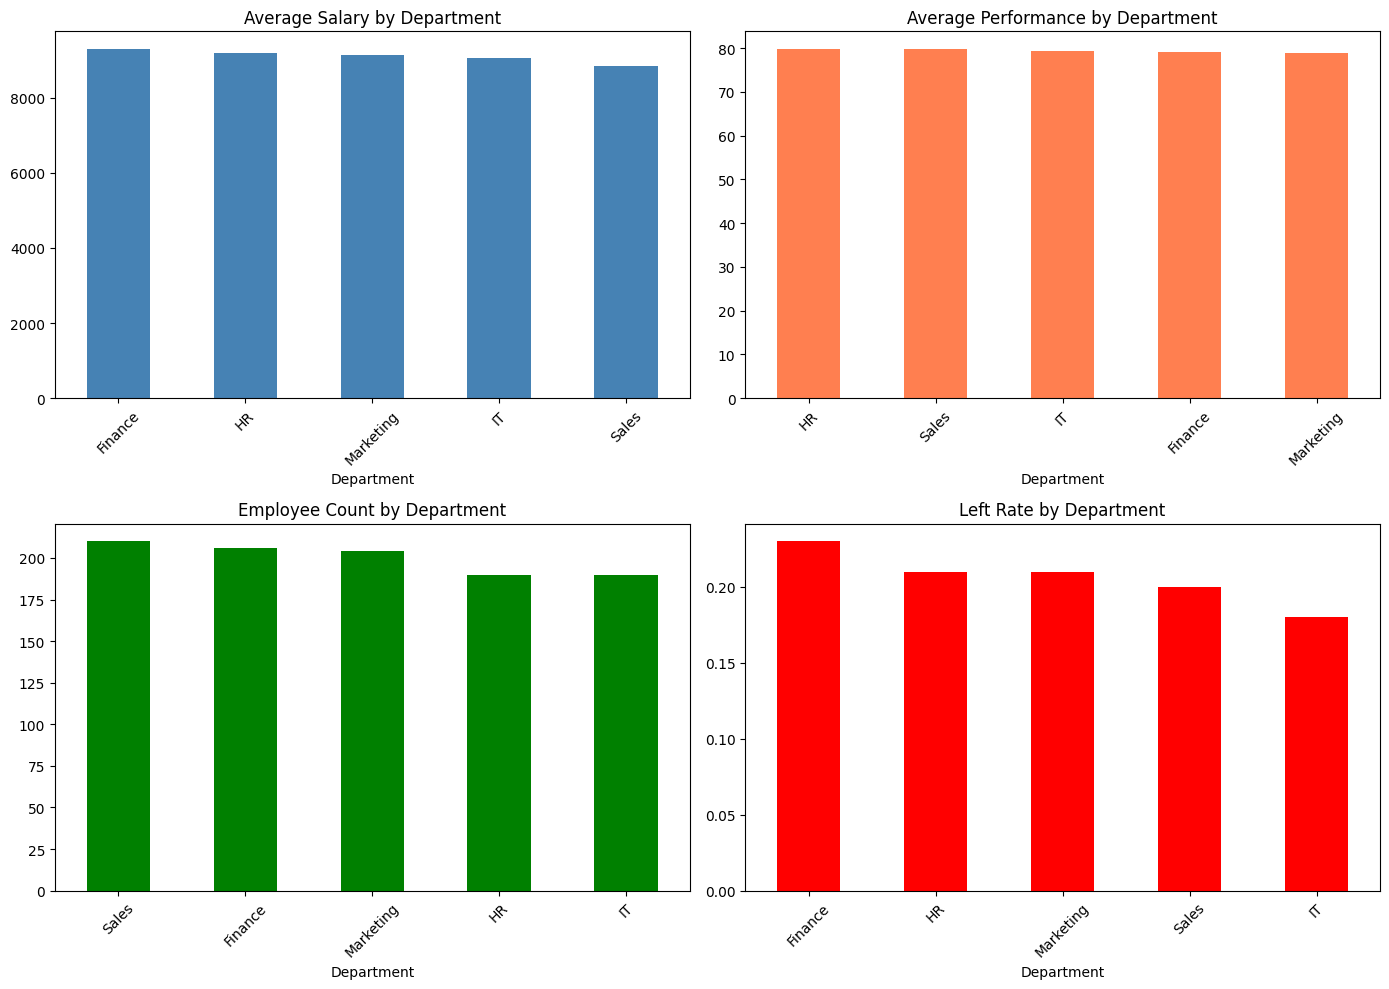

In [5]:
# Step 4: Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Chart 1: Average Salary by Department
df.groupby('Department')['Salary'].mean().round(2).sort_values(ascending=False).plot( kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Average Salary by Department')
axes[0,0].set_xlabel('Department')
axes[0,0].tick_params(axis='x', rotation=45)
# Chart 2: Average Performance by Department
df.groupby('Department')['Performance'].mean().round(2).sort_values(ascending=False).plot( kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Average Performance by Department')
axes[0,1].set_xlabel('Department')
axes[0,1].tick_params(axis='x', rotation=45)
# Chart 3: Employee Count by Department
df['Department'].value_counts().plot( kind='bar', ax=axes[1,0], color='green')
axes[1,0].set_title('Employee Count by Department')
axes[1,0].set_xlabel('Department')
axes[1,0].tick_params(axis='x', rotation=45)
# Chart 4: Left Rate by Department
df.groupby('Department')['Left_Company'].mean().round(2).sort_values(ascending=False).plot(kind='bar', ax=axes[1,1], color='red')
axes[1,1].set_title('Left Rate by Department')
axes[1,1].set_xlabel('Department')
axes[1,1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()